# Exploratory data analysis

Датасет представляет собой записи о погодных и временных условия, которые могут теоритически коррелировать с кол-вом велосипедов, которые берутся в аренду

## Импорты

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import numpy as np

## Загрузка датасета

In [7]:
raw_bikes = pd.read_csv("./datasets/raw.csv")

raw_bikes.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


В датасете 14 полей, описание каждого

- `dteday` - Дата
- `season` - 1:Зима, 2:Весна, 3:Лето, 4:Осень
- `yr` - Год (0: 2011, 1: 2012)
- `mnth` - месяц (1 to 12)
- `hr` - час (0 to 23)
- `holiday` - Является ли день праздничным (0:Обычный, 1:Праздничный)
- `weekday` - день недели
- `workingday` - Является ли день выходным или праздничным (1:Обычный день, 0:Праздничный или выходной)
- `weathersit` - - 1: Чисто, 2: Легкая облачность, Частичная облачность, Частичная облачность (Опять?)
- `temp` - Нормализованная температура в цельсиях
- `atemp` - Нормализованная "ощущаемая" температура в цельсиях
- `hum` - Нормализованная влажность
- `windspeed` - Нормализованная скорость векра
- `cnt` - целевая переменная: общее кол-ов арендаторов

In [8]:
raw_bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 1.9 MB


Как видно, в датасете отсутствуют пропуски

## Анализ одной переменной

### Целевая переменная

Проанализирую распределение целевой переменной cnt

<Axes: xlabel='cnt', ylabel='Count'>

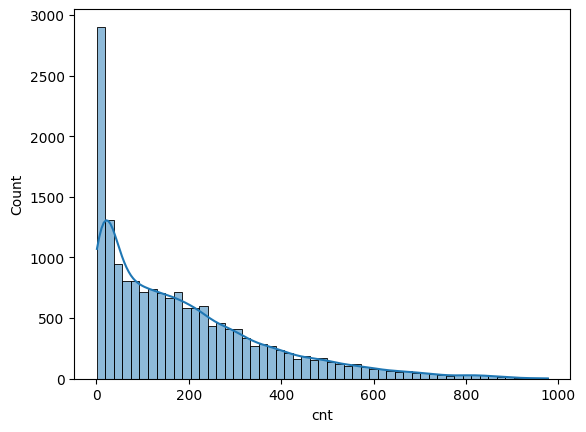

In [ ]:
sns.histplot(data=raw_bikes["cnt"], kde=True)

По графику понятно, что чаще всего кол-во ареднованных велосипедов оказывает около нуля. Длинный хвост справа

<Axes: xlabel='cnt', ylabel='Count'>

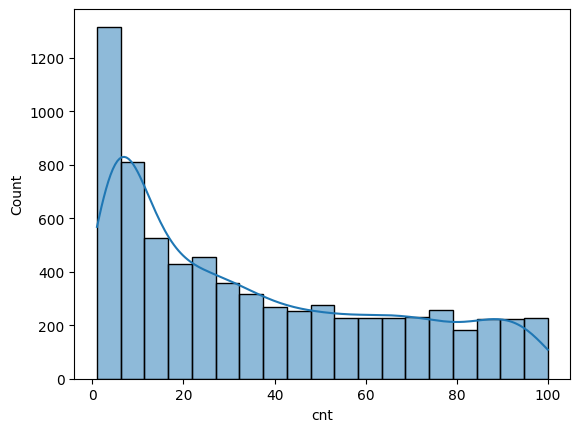

In [17]:
sns.histplot(data=raw_bikes[raw_bikes["cnt"] <= 100]["cnt"], kde=True)

In [23]:
for i in range(0, 10):
    print(f"Кол-во значений {i}: {len(raw_bikes[raw_bikes["cnt"] == i])}")

Кол-во значений 0: 0
Кол-во значений 1: 158
Кол-во значений 2: 208
Кол-во значений 3: 224
Кол-во значений 4: 231
Кол-во значений 5: 260
Кол-во значений 6: 236
Кол-во значений 7: 198
Кол-во значений 8: 182
Кол-во значений 9: 128


На промежутке от 0 до 100 видно, что достотаточно часто кол-во велосипедов в аренде около нуля, однако значений 0 нет, мода от 0 до 9 = 5

### Погодные значения

Проведу анализ распределений погодных значений

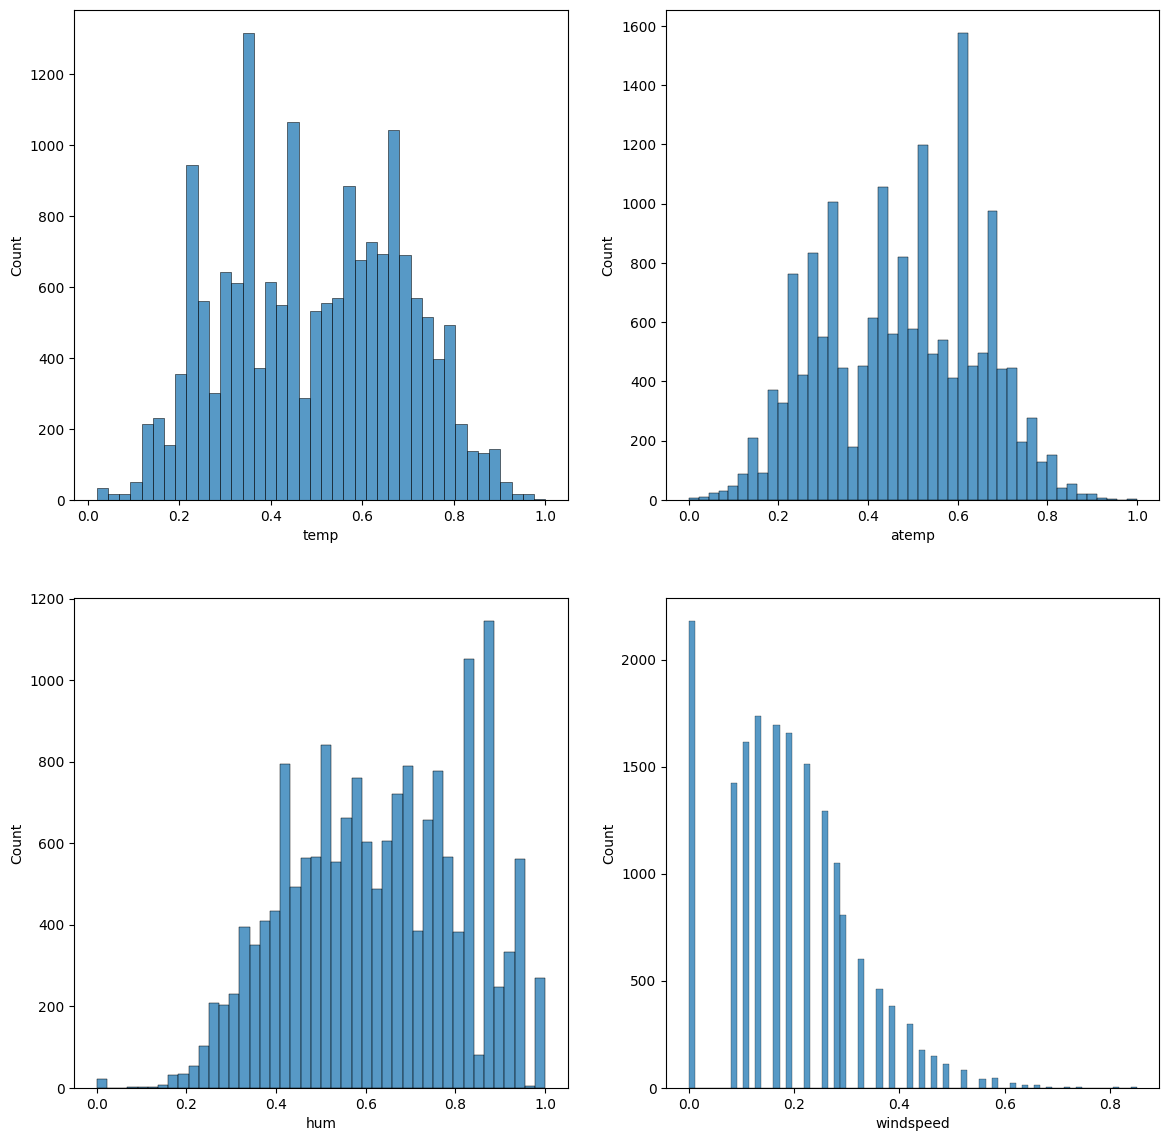

In [39]:
fig, ax = plt.subplots(2, 2)

cols = ["temp", "atemp", "hum", "windspeed"]

for i, axis in enumerate(ax.flatten()):
    sns.histplot(data=raw_bikes[cols[i]], ax=axis)

fig.set_size_inches(14, 14)

По гистограммам понятно, что данные распределены нормально, влажность и скорость ветра немного смещены

## Анализ по многим переменным